In [1]:
# CELL 1 - Install libraries
!pip install PyMuPDF gensim scikit-learn matplotlib seaborn wordcloud -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

CORPUS_PATH = '/content/drive/MyDrive/NLP_Corpus'

Mounted at /content/drive


In [3]:
import os
print(os.listdir(CORPUS_PATH))


['CloudComputing', 'DataScience', 'Robotics', 'Cybersecurity', 'AI']


In [4]:
# CELL 3 - Extract text from all PDFs
import fitz  # PyMuPDF
import os
import pandas as pd

def extract_pdf_text(pdf_path):
    text = ""
    try:
        doc = fitz.open(pdf_path)
        for page in doc:
            text += page.get_text()
        doc.close()
    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")
    return text

data = []
for category in os.listdir(CORPUS_PATH):
    cat_folder = os.path.join(CORPUS_PATH, category)
    if os.path.isdir(cat_folder):
        for fname in os.listdir(cat_folder):
            if fname.lower().endswith('.pdf'):
                fpath = os.path.join(cat_folder, fname)
                raw_text = extract_pdf_text(fpath)
                data.append({
                    'file_name': fname,
                    'category': category,
                    'raw_text': raw_text
                })

df = pd.DataFrame(data)
print(f"Total files extracted: {len(df)}")
df.head()

Total files extracted: 50


,file_name,category,raw_text
0,Cloud_Storage_Solutions.pdf,CloudComputing,Cloud Storage Solutions\nCloud storage refers ...
1,Cloud_Networking_Fundamentals.pdf,CloudComputing,Cloud Networking Fundamentals\nCloud networkin...
2,Cloud_Service_Models_IaaS_PaaS_SaaS.pdf,CloudComputing,Cloud Service Models IaaS PaaS SaaS\nCloud com...
3,Cloud_Security_and_Compliance.pdf,CloudComputing,Cloud Security and Compliance\nSecurity remain...
4,Cloud_Cost_Optimization.pdf,CloudComputing,Cloud Cost Optimization\nManaging and optimizi...


In [5]:
# CELL 4 - Cleaning
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # URL removal
    text = re.sub(r'\S+@\S+', '', text)                  # Email removal
    text = re.sub(r'\d+', '', text)                       # Number removal
    text = re.sub(r'[^\w\s]', '', text)                   # Punctuation removal
    text = re.sub(r'\s+', ' ', text).strip()               # Extra space normalization
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]    # Stopword removal
    tokens = [t for t in tokens if len(t) > 2]             # Remove short tokens
    return ' '.join(tokens), tokens

df['cleaned_text'], df['tokens'] = zip(*df['raw_text'].apply(clean_text))
df.to_csv('nlp_corpus_dataset.csv', index=False)
df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,file_name,category,raw_text,cleaned_text,tokens
0,Cloud_Storage_Solutions.pdf,CloudComputing,Cloud Storage Solutions\nCloud storage refers ...,cloud storage solutions cloud storage refers p...,"[cloud, storage, solutions, cloud, storage, re..."
1,Cloud_Networking_Fundamentals.pdf,CloudComputing,Cloud Networking Fundamentals\nCloud networkin...,cloud networking fundamentals cloud networking...,"[cloud, networking, fundamentals, cloud, netwo..."
2,Cloud_Service_Models_IaaS_PaaS_SaaS.pdf,CloudComputing,Cloud Service Models IaaS PaaS SaaS\nCloud com...,cloud service models iaas paas saas cloud comp...,"[cloud, service, models, iaas, paas, saas, clo..."
3,Cloud_Security_and_Compliance.pdf,CloudComputing,Cloud Security and Compliance\nSecurity remain...,cloud security compliance security remains one...,"[cloud, security, compliance, security, remain..."
4,Cloud_Cost_Optimization.pdf,CloudComputing,Cloud Cost Optimization\nManaging and optimizi...,cloud cost optimization managing optimizing co...,"[cloud, cost, optimization, managing, optimizi..."


In [6]:
# CELL 5 - N-gram versions
from nltk.util import ngrams

def get_ngram_tokens(tokens, n):
    if n == 1:
        return tokens
    return ['_'.join(g) for g in ngrams(tokens, n)]

df['unigrams'] = df['tokens'].apply(lambda x: get_ngram_tokens(x, 1))
df['bigrams']  = df['tokens'].apply(lambda x: get_ngram_tokens(x, 2))
df['trigrams'] = df['tokens'].apply(lambda x: get_ngram_tokens(x, 3))

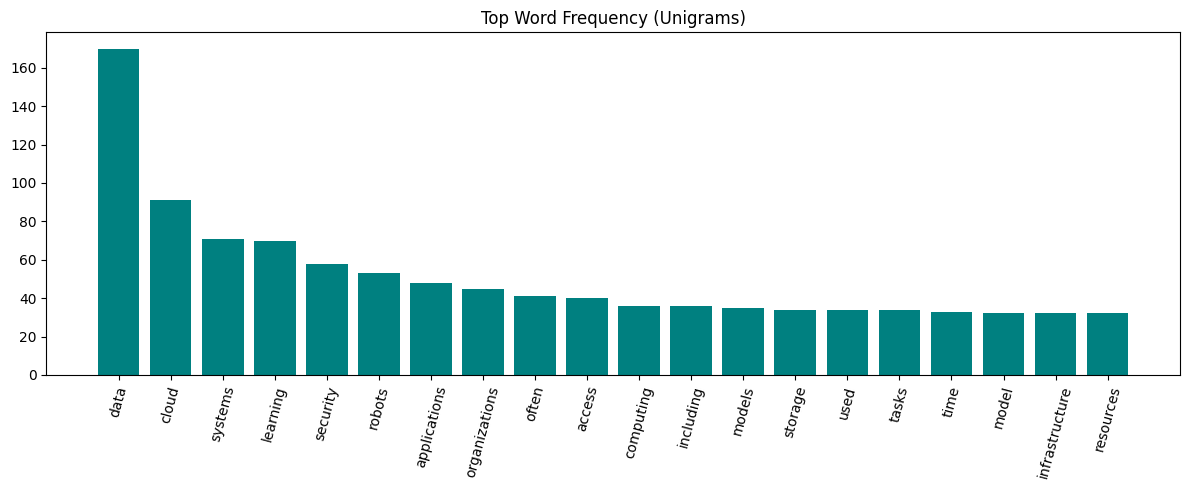

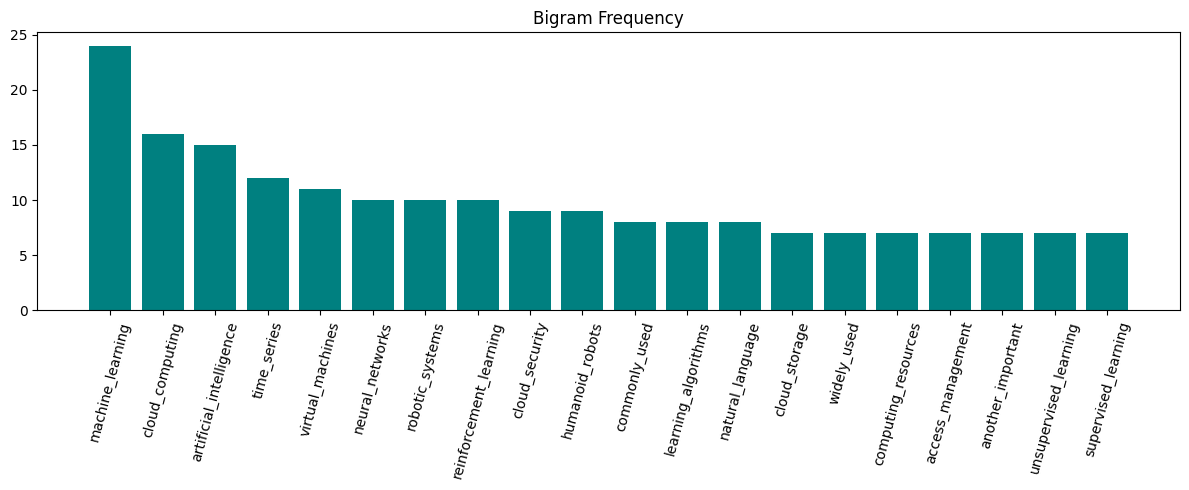

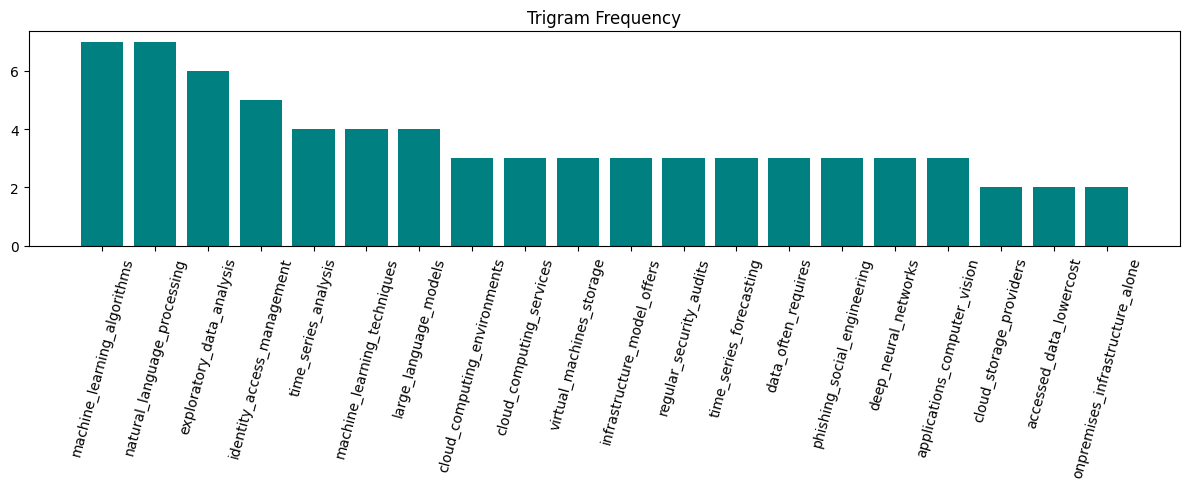

In [7]:
# CELL 6 - Frequency graphs
import matplotlib.pyplot as plt
from collections import Counter

def plot_top_words(all_tokens, title, top_n=20):
    counts = Counter(all_tokens)
    common = counts.most_common(top_n)
    words, freqs = zip(*common)
    plt.figure(figsize=(12,5))
    plt.bar(words, freqs, color='teal')
    plt.xticks(rotation=75)
    plt.title(title)
    plt.tight_layout()
    plt.show()

all_unigrams = [w for row in df['unigrams'] for w in row]
all_bigrams  = [w for row in df['bigrams'] for w in row]
all_trigrams = [w for row in df['trigrams'] for w in row]

plot_top_words(all_unigrams, "Top Word Frequency (Unigrams)")
plot_top_words(all_bigrams, "Bigram Frequency")
plot_top_words(all_trigrams, "Trigram Frequency")

In [8]:
# CELL 7 - Train CBOW and Skip-gram on unigram/bigram/trigram corpora
from gensim.models import Word2Vec

def train_w2v(sentences, sg):
    return Word2Vec(sentences=sentences, vector_size=100, window=5,
                     min_count=1, sg=sg, epochs=20)

# sg=0 -> CBOW, sg=1 -> Skip-gram
uni_sentences = df['unigrams'].tolist()
bi_sentences  = df['bigrams'].tolist()
tri_sentences = df['trigrams'].tolist()

cbow_uni = train_w2v(uni_sentences, sg=0)
skip_uni = train_w2v(uni_sentences, sg=1)

cbow_bi = train_w2v(bi_sentences, sg=0)
skip_bi = train_w2v(bi_sentences, sg=1)

cbow_tri = train_w2v(tri_sentences, sg=0)
skip_tri = train_w2v(tri_sentences, sg=1)

print("All 6 models trained (CBOW & Skip-gram x unigram/bigram/trigram)")

All 6 models trained (CBOW & Skip-gram x unigram/bigram/trigram)


CBOW (unigram): [('resources', 0.9997290372848511), ('storage', 0.9996649622917175), ('organizations', 0.9996536374092102), ('network', 0.9996410012245178), ('allowing', 0.9996234178543091)]
Skip-gram (unigram): [('computing', 0.9803986549377441), ('resources', 0.9682796597480774), ('storage', 0.968224048614502), ('services', 0.9626311659812927), ('provider', 0.9582064747810364)]


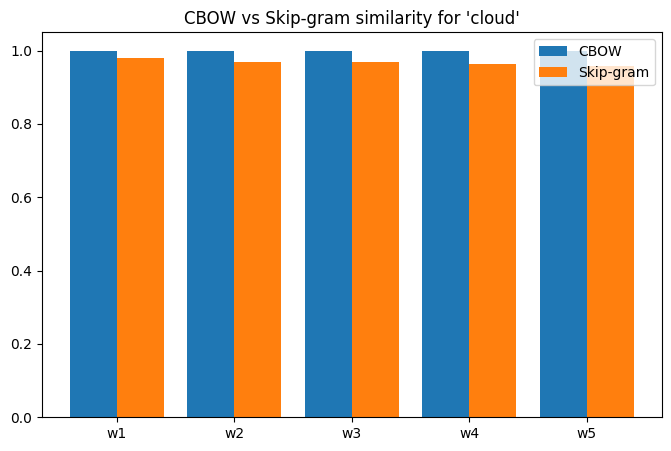

In [9]:
# CELL 8 - Prediction function + comparison
def predict_next_words(model, word, topn=5):
    try:
        return model.wv.most_similar(word, topn=topn)
    except KeyError:
        return f"'{word}' not in vocabulary"

# Example words - use words that appear in your actual corpus
test_word = all_unigrams[0]  # pick a real word from your corpus
print("CBOW (unigram):", predict_next_words(cbow_uni, test_word))
print("Skip-gram (unigram):", predict_next_words(skip_uni, test_word))

# Comparison graph - similarity scores
import numpy as np

def get_scores(model, word):
    res = predict_next_words(model, word)
    if isinstance(res, str):
        return [], []
    words, scores = zip(*res)
    return words, scores

w_cbow, s_cbow = get_scores(cbow_uni, test_word)
w_skip, s_skip = get_scores(skip_uni, test_word)

x = np.arange(5)
plt.figure(figsize=(8,5))
plt.bar(x-0.2, s_cbow, width=0.4, label='CBOW')
plt.bar(x+0.2, s_skip, width=0.4, label='Skip-gram')
plt.xticks(x, [f"w{i+1}" for i in range(5)])
plt.title(f"CBOW vs Skip-gram similarity for '{test_word}'")
plt.legend()
plt.show()

In [10]:
# CELL 9 - Vectorize and train classifiers on unigram/bigram/trigram
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = {}

def build_text(gram_list):
    return [' '.join(row) for row in gram_list]

feature_sets = {
    'unigram': build_text(df['unigrams']),
    'bigram': build_text(df['bigrams']),
    'trigram': build_text(df['trigrams'])
}

y = df['category']

for gram_name, texts in feature_sets.items():
    vec = CountVectorizer(max_features=3000)
    X = vec.fit_transform(texts)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    for model_name, model in [('NaiveBayes', MultinomialNB()),
                                ('LogisticRegression', LogisticRegression(max_iter=1000))]:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)
        prec = precision_score(y_test, preds, average='weighted', zero_division=0)
        rec = recall_score(y_test, preds, average='weighted', zero_division=0)
        f1 = f1_score(y_test, preds, average='weighted', zero_division=0)
        results[f"{model_name}_{gram_name}"] = {
            'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_test': y_test, 'preds': preds
        }
        print(f"{model_name} ({gram_name}): Acc={acc:.3f} F1={f1:.3f}")

NaiveBayes (unigram): Acc=0.900 F1=0.893
LogisticRegression (unigram): Acc=1.000 F1=1.000
NaiveBayes (bigram): Acc=0.900 F1=0.893
LogisticRegression (bigram): Acc=0.800 F1=0.800
NaiveBayes (trigram): Acc=0.600 F1=0.527
LogisticRegression (trigram): Acc=0.600 F1=0.527


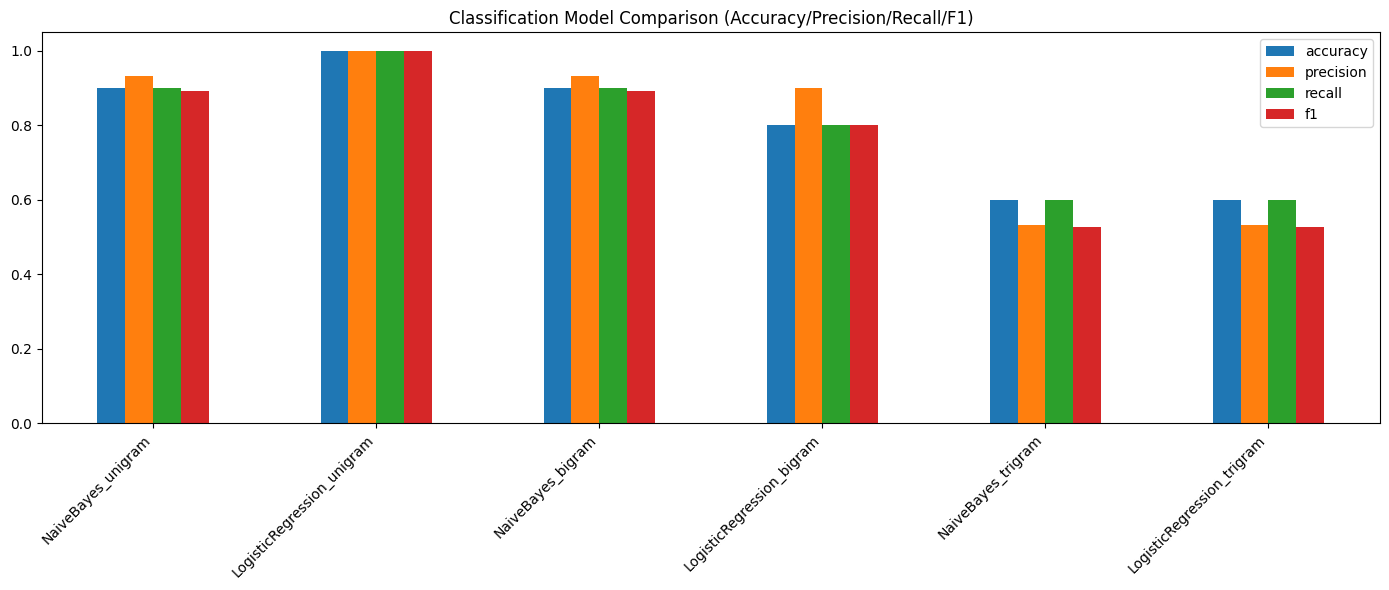

Best model: LogisticRegression_unigram


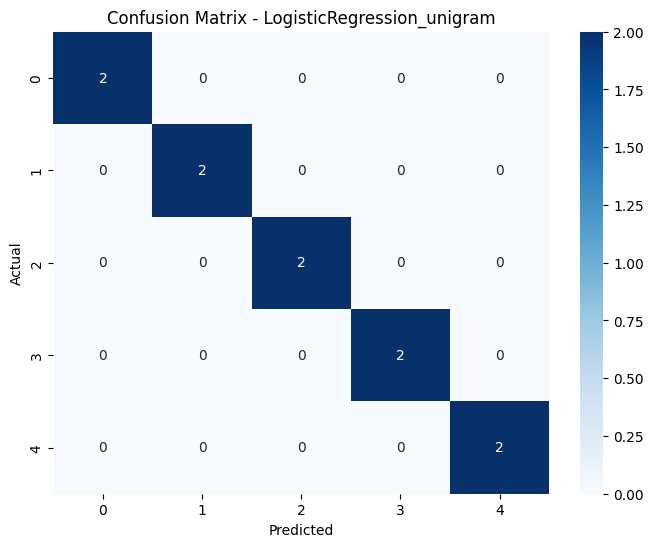

In [11]:
# CELL 10 - Comparison graph
res_df = pd.DataFrame(results).T[['accuracy','precision','recall','f1']].astype(float)
res_df.plot(kind='bar', figsize=(14,6))
plt.title("Classification Model Comparison (Accuracy/Precision/Recall/F1)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Confusion matrix for best model
best_key = res_df['f1'].idxmax()
print("Best model:", best_key)

import seaborn as sns
cm = confusion_matrix(results[best_key]['y_test'], results[best_key]['preds'])
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_key}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cluster         0  1   2  3  4
category                      
AI              0  0  10  0  0
CloudComputing  0  5   0  5  0
Cybersecurity   0  0   0  1  9
DataScience     0  0   4  0  6
Robotics        9  0   1  0  0


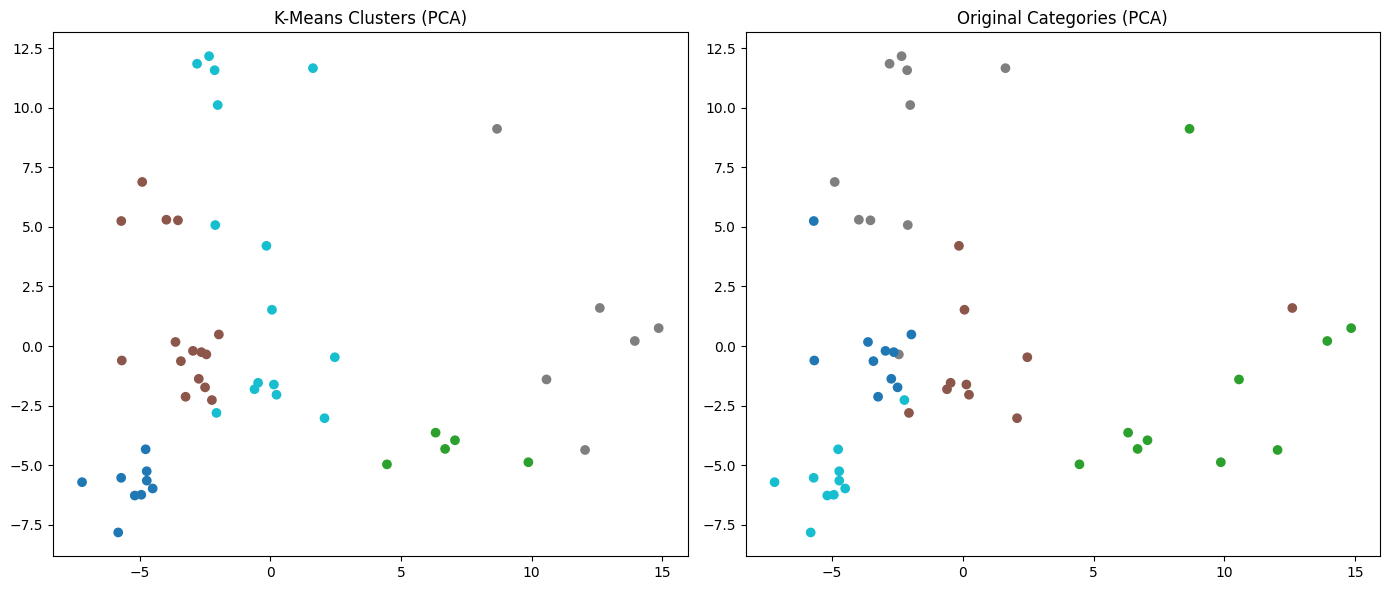

In [12]:
# CELL 11 - K-means + visualization
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Use unigram vectors (or whichever performed best above)
vec = CountVectorizer(max_features=3000)
X_full = vec.fit_transform(build_text(df['unigrams'])).toarray()

n_clusters = df['category'].nunique()
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_full)

df['cluster'] = cluster_labels

# Compare clusters to original categories
le = LabelEncoder()
true_labels = le.fit_transform(df['category'])

comparison = pd.crosstab(df['category'], df['cluster'])
print(comparison)

# PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_full)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
scatter1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, cmap='tab10')
axes[0].set_title("K-Means Clusters (PCA)")
scatter2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=true_labels, cmap='tab10')
axes[1].set_title("Original Categories (PCA)")
plt.tight_layout()
plt.show()